# Exploratory Data Analysis and Feature Engineering:

**Author:** Mridankan Mandal  
**Roll Number:** IIB2024017

---

## Notebook Overview:
- This notebook is executed on the cleaned datasets produced by `clean_data.ipynb`.
- An exploratory data analysis (EDA) is first conducted to uncover class imbalances, missingness patterns, and distributional characteristics of key features.
- Twelve engineered features are subsequently derived from textual, geometric, binary, temporal, and external signal sources to maximise the predictive signal available to downstream classifiers.
- Correlation analyses and rich visualisations are presented to substantiate each feature's discriminative utility.
- The final feature-enriched DataFrames are saved to `data/processed/` as `train_fe.csv` and `test_fe.csv`.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="darkgrid", palette="tab10")
plt.rcParams.update({'font.size': 12, 'figure.figsize': (12, 6)})


In [2]:
# Load clean datasets
train = pd.read_csv('data/processed/train_clean.csv')
test = pd.read_csv('data/processed/test_clean.csv')

IMG_TRAIN_DIR = 'data/raw/images/train'
IMG_TEST_DIR = 'data/raw/images/test'

for df in [train, test]:
    df['is_portrait'] = (df['height'] > df['width']).astype(int)
    df['is_landscape'] = (df['width'] > df['height']).astype(int)
    df['surface_area'] = df['width'] * df['height']

print(f"Train Base Shape: {train.shape}")
print(f"Test Base Shape: {test.shape}")


Train Base Shape: (4000, 64)
Test Base Shape: (1000, 63)


## 1. Visual Exploratory Data Analysis (EDA):
- The training set's target-class distribution is examined to detect imbalances that
  could bias model evaluation; the count-plot is sorted by frequency for readability.
- Missing value rates are computed per feature and visualised as a horizontal bar chart,
  guiding decisions on imputation strategy and feature inclusion thresholds.
- Temporal metadata (`y0`, `y1`) is interrogated for anomalies such as implausible year
  values, and KDE plots of numeric features by class surface distributional differences.


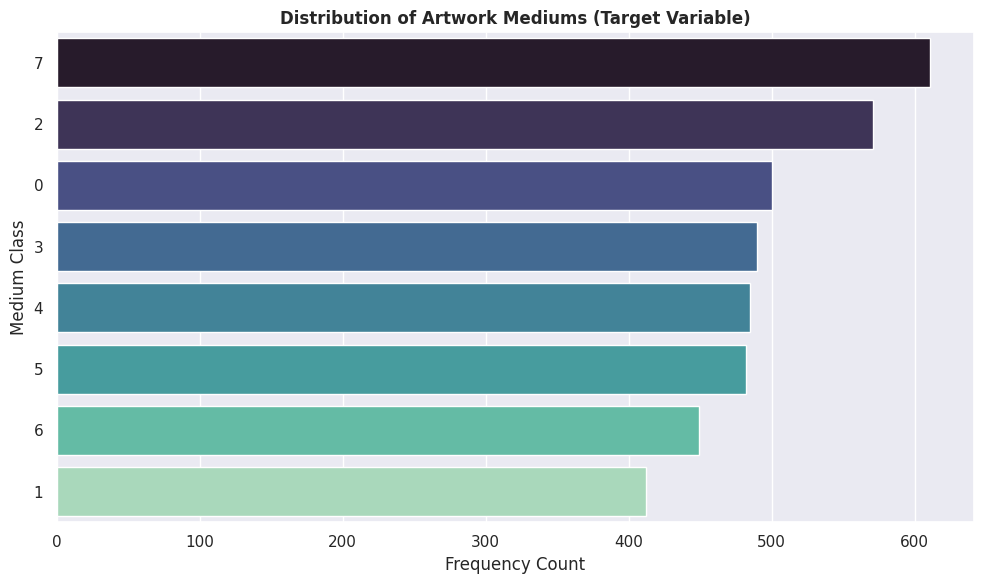

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
order = train['y'].value_counts().index
sns.countplot(data=train, y='y', order=order, palette='mako')
ax.set_title("Distribution of Artwork Mediums (Target Variable)", fontweight='bold')
ax.set_xlabel("Frequency Count")
ax.set_ylabel("Medium Class")
plt.tight_layout()
plt.show()


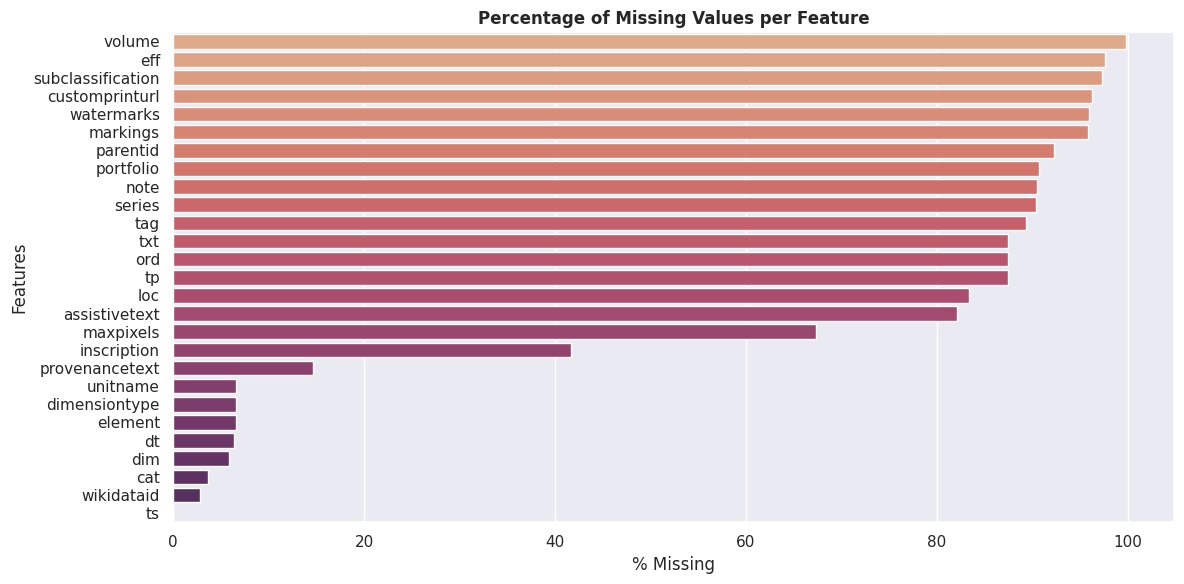

In [4]:
missing_pct = (train.isnull().sum() / len(train)) * 100
missing_features = missing_pct[missing_pct > 0].sort_values(ascending=False)
if len(missing_features) > 0:
    plt.figure(figsize=(12, 6))
    sns.barplot(x=missing_features.values, y=missing_features.index, palette='flare')
    plt.title("Percentage of Missing Values per Feature", fontweight='bold')
    plt.xlabel("% Missing")
    plt.ylabel("Features")
    plt.tight_layout()
    plt.show()


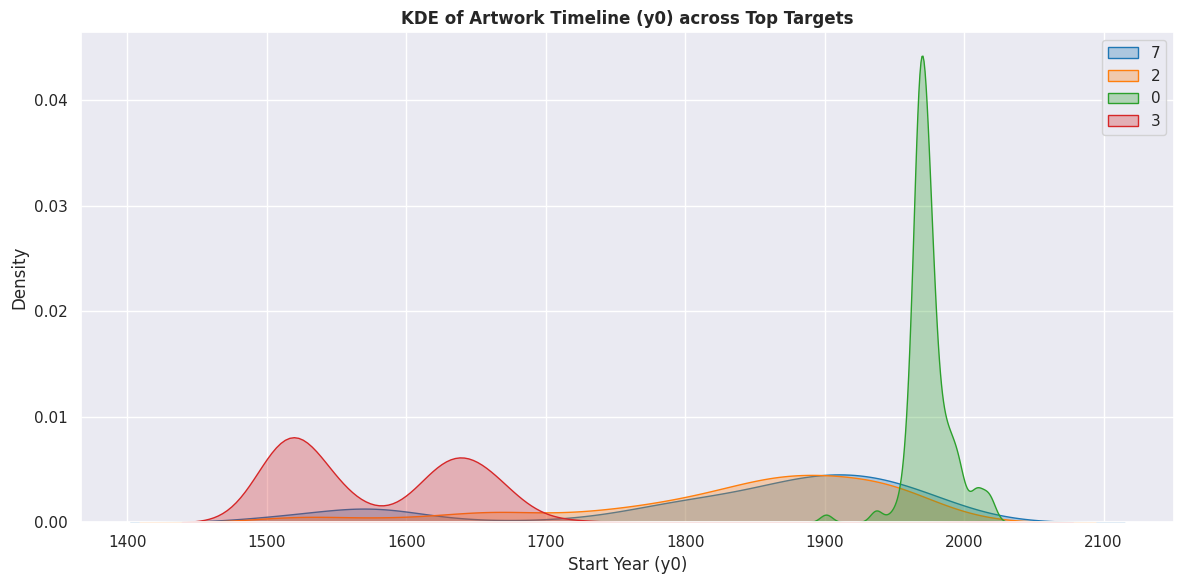

In [5]:
plt.figure(figsize=(12, 6))
top_targets = train['y'].value_counts().head(4).index
for cat in top_targets:
    sns.kdeplot(train[(train['y'] == cat) & (train['y0'] > 1500)]['y0'], label=cat, fill=True, alpha=0.3)
plt.title("KDE of Artwork Timeline (y0) across Top Targets", fontweight='bold')
plt.xlabel("Start Year (y0)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


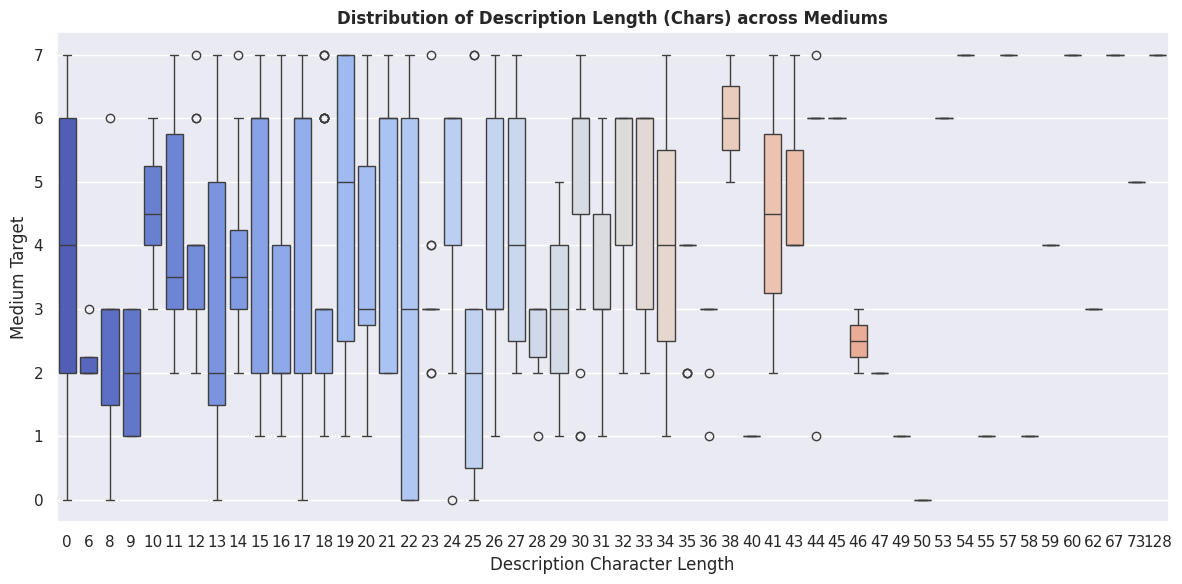

In [6]:
train['desc_len'] = train['txt'].fillna('').apply(lambda x: len(str(x)))
plt.figure(figsize=(12, 6))
sns.boxplot(data=train[train['desc_len'] < 2000], x='desc_len', y='y', palette='coolwarm')
plt.title("Distribution of Description Length (Chars) across Mediums", fontweight='bold')
plt.xlabel("Description Character Length")
plt.ylabel("Medium Target")
plt.tight_layout()
plt.show()


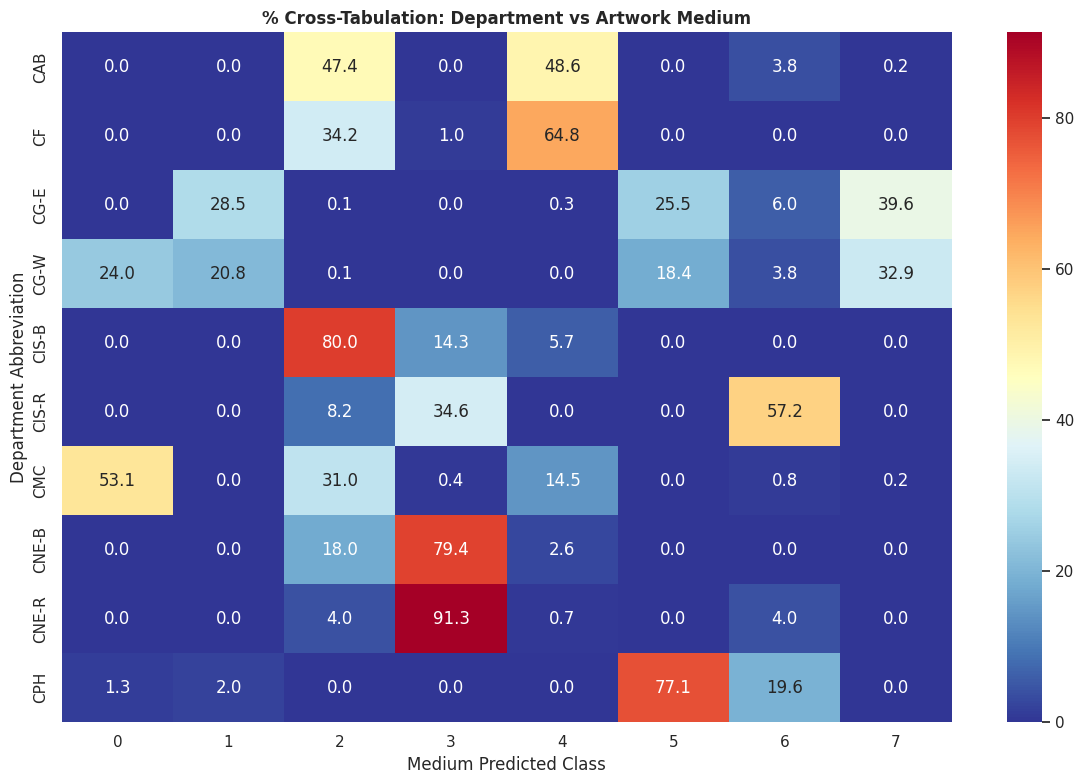

In [7]:
dep_target = pd.crosstab(train['departmentabbr'], train['y'], normalize='index') * 100
plt.figure(figsize=(12, 8))
sns.heatmap(dep_target, annot=True, cmap='RdYlBu_r', fmt='.1f')
plt.title("% Cross-Tabulation: Department vs Artwork Medium", fontweight='bold')
plt.xlabel("Medium Predicted Class")
plt.ylabel("Department Abbreviation")
plt.tight_layout()
plt.show()


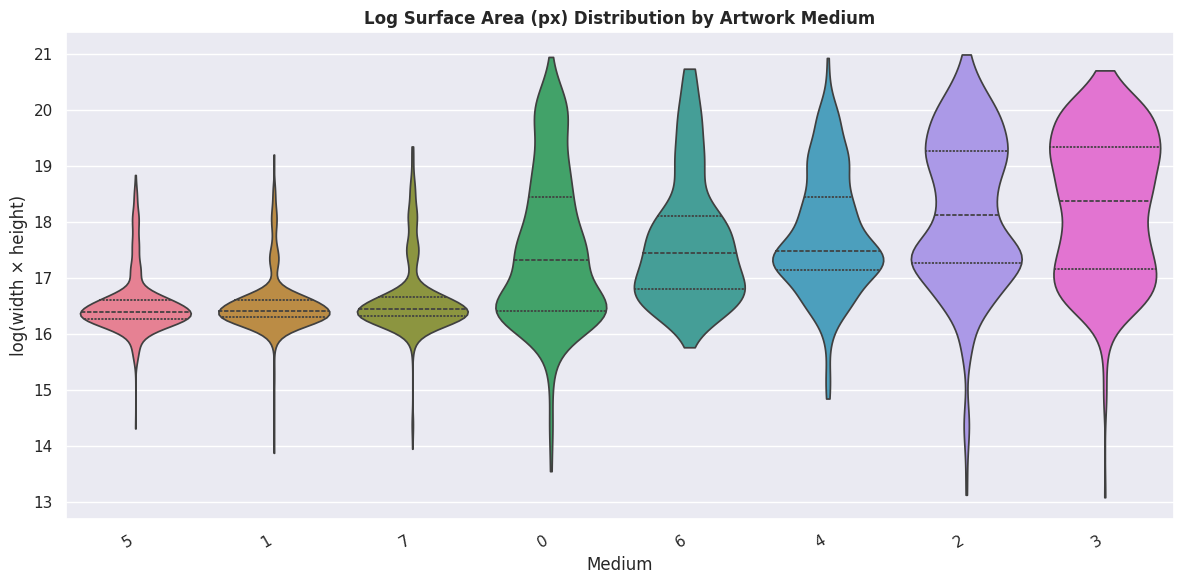

Surface area (px^2) medians per medium:
y
3    94734316.0
2    74614176.0
4    39250068.0
6    37275304.0
0    33023689.5
7    13725162.0
1    13288000.0
5    13122104.0


In [8]:
# 6. Surface Area Distribution by Medium (Log-Scale Violin Plot)
# Width and height represent IIIF pixel dimensions (min > 400px), so a raw
# scatter with <400 mask yields zero rows. Instead, we visualize log(surface area)
# which reveals how physical canvas scale separates the medium classes.
import numpy as np

train['log_surface_area'] = np.log1p(train['width'] * train['height'])

fig, ax = plt.subplots(figsize=(12, 6))
order = train.groupby('y')['log_surface_area'].median().sort_values().index
sns.violinplot(data=train, x='y', y='log_surface_area', order=order,
               palette='husl', inner='quartile', cut=0, ax=ax)
ax.set_title("Log Surface Area (px) Distribution by Artwork Medium", fontweight='bold')
ax.set_xlabel("Medium")
ax.set_ylabel("log(width × height)")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print("Surface area (px^2) medians per medium:")
print((train['width'] * train['height']).groupby(train['y']).median().sort_values(ascending=False).to_string())


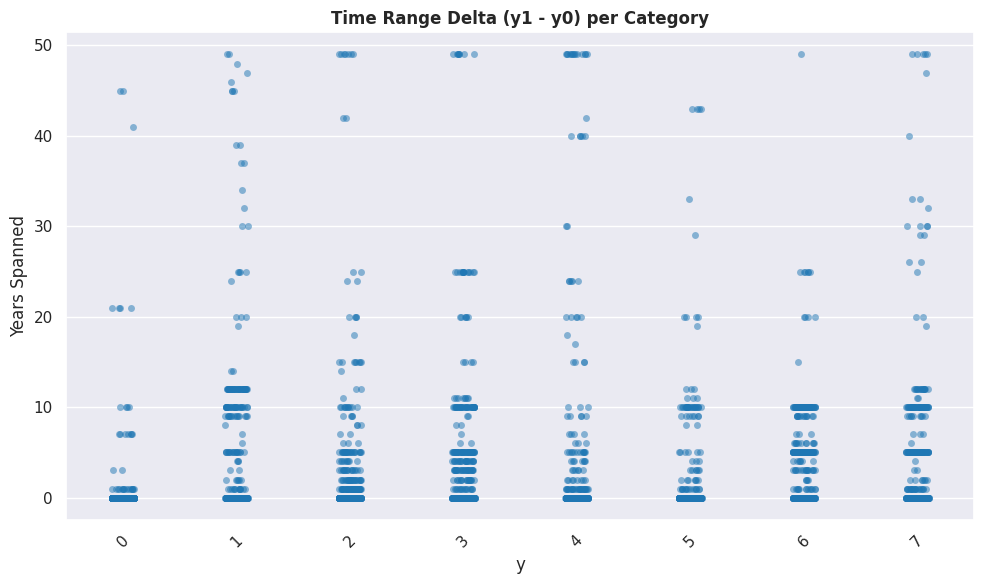

In [9]:
train['lifespan'] = train['y1'] - train['y0']
plt.figure(figsize=(10, 6))
sns.stripplot(data=train[(train['lifespan'] >= 0) & (train['lifespan'] < 50)], x='y', y='lifespan', jitter=True, alpha=0.5)
plt.title("Time Range Delta (y1 - y0) per Category", fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel("Years Spanned")
plt.tight_layout()
plt.show()


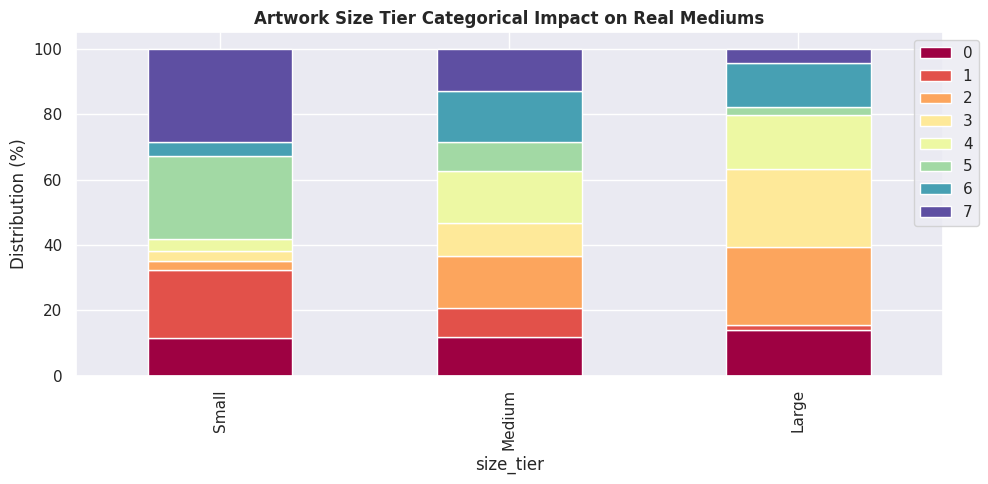

In [10]:
train['size_tier'] = pd.qcut(train['surface_area'].clip(0), q=3, labels=['Small', 'Medium', 'Large'], duplicates='drop')
size_target = pd.crosstab(train['size_tier'], train['y'], normalize='index') * 100
plt.figure(figsize=(10, 5))
size_target.plot(kind='bar', stacked=True, colormap='Spectral', ax=plt.gca())
plt.title("Artwork Size Tier Categorical Impact on Real Mediums", fontweight='bold')
plt.ylabel("Distribution (%)")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


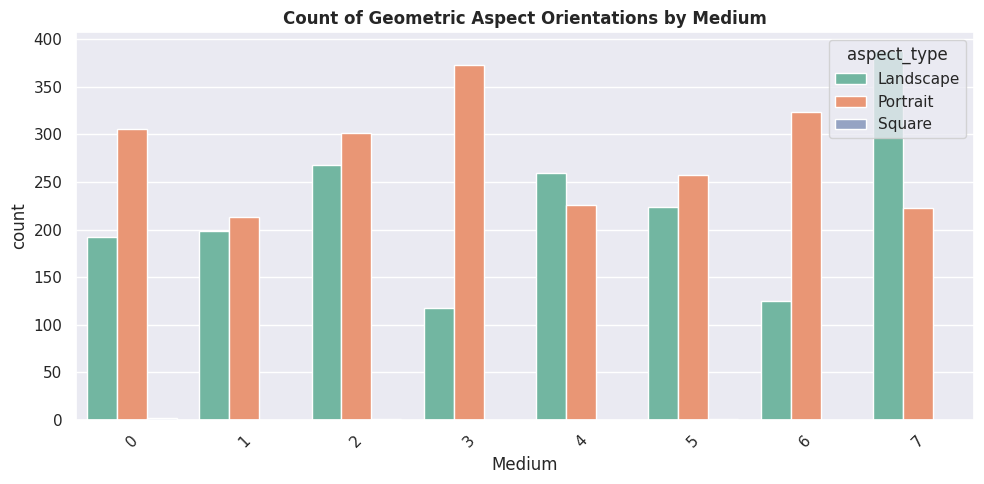

In [11]:
train['aspect_type'] = 'Square'
train.loc[train['is_portrait'] == 1, 'aspect_type'] = 'Portrait'
train.loc[train['is_landscape'] == 1, 'aspect_type'] = 'Landscape'
plt.figure(figsize=(10, 5))
sns.countplot(data=train, x='y', hue='aspect_type', palette='Set2')
plt.title("Count of Geometric Aspect Orientations by Medium", fontweight='bold')
plt.xticks(rotation=45)
plt.xlabel("Medium")
plt.tight_layout()
plt.show()


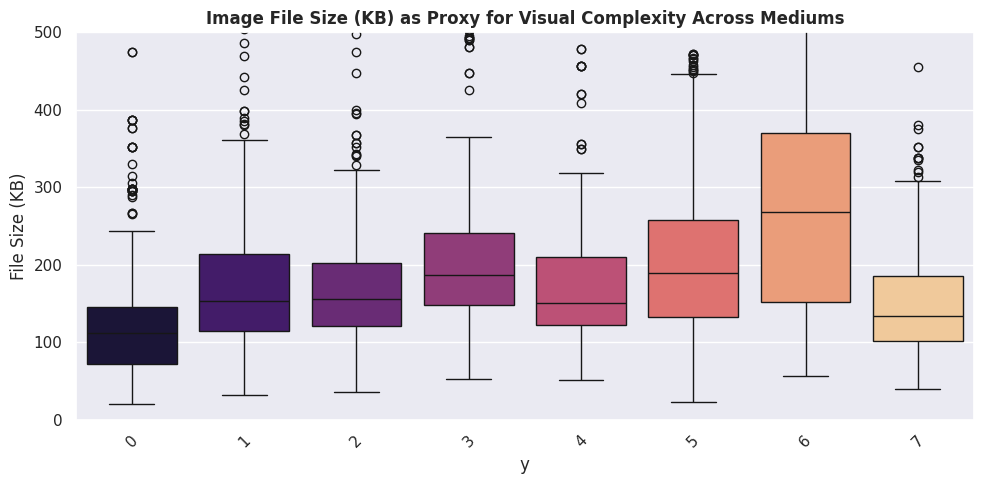

In [12]:
train_sizes = []
for i in train['id']:
    img_path = os.path.join(IMG_TRAIN_DIR, f"{i}.jpg")
    train_sizes.append(os.path.getsize(img_path) / 1024 if os.path.exists(img_path) else -1)
train['img_size_kb'] = train_sizes
plt.figure(figsize=(10, 5))
sns.boxplot(data=train[train['img_size_kb'] > 0], x='y', y='img_size_kb', palette='magma')
plt.title("Image File Size (KB) as Proxy for Visual Complexity Across Mediums", fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel("File Size (KB)")
plt.ylim(0, 500)
plt.tight_layout()
plt.show()


## 2. Feature Engineering:
- Twelve complementary features are derived from the cleaned dataset to capture diverse predictive signals.
- **Orientation flags** (`is_portrait`, `is_landscape`): Binary indicators derived from `height > width`
  and `width > height` reflect the physical orientation convention favoured by different media.
- **Surface area** (`surface_area = width x height`): Captures the absolute canvas extent;
  larger artworks tend to be oils rather than watercolours or prints.
- **Textual density** (`cap_len`, `txt_len`, `t_len`, `cap_word_count`, `txt_word_count`):
  Character and word counts of caption, description, and title fields encode curatorial verbosity,
  which differs systematically across media.
- **Aspect ratio** (`aspect_ratio = width / height`): Encodes the proportional shape of the canvas;
  golden-ratio proximity is further flagged.
- **Golden ratio flag** (`golden_ratio_flag`): A binary feature set to 1 when the aspect ratio falls
  within +/-10% of 1.618, capturing artworks whose canvases conform to this classical proportion.
- **Image availability** (`has_img`): A binary flag indicating whether an image URL is provided,
  which may correlate with institutional digitisation priorities.
- **Year span** (`year_span = y1 - y0`): Captures the range of years attributed to a work;
  multi-century spans occur for manuscript illuminations but not for modern oils.


In [13]:
def engineer_kagglestyle_features(df, is_train=True):
    import os
    import numpy as np
    import pandas as pd
    from PIL import Image
    import cv2
    import torch
    from transformers import AutoProcessor, AutoModelForZeroShotImageClassification
    from tqdm.auto import tqdm
    import gc
    
    out = df.copy()
    
    out['txt_word_count'] = out['txt'].fillna('').apply(lambda x: len(str(x).split()))
    out['title_word_count'] = out['t'].fillna('').apply(lambda x: len(str(x).split()))
    out['has_numeric_date'] = out['dt'].fillna('').apply(lambda x: 1 if any(char.isdigit() for char in str(x)) else 0)
    
    # OS image size parsing & complexity
    image_dir = IMG_TRAIN_DIR if is_train else IMG_TEST_DIR
    sizes = []
    complexities = []
    for i in tqdm(out['id'], desc="Size & Complexity"):
        p = os.path.join(image_dir, f"{i}.jpg")
        if os.path.exists(p):
            sizes.append(os.path.getsize(p) / 1024)
            try:
                img = Image.open(p).convert('L')
                img_arr = np.array(img.resize((128, 128)))
                lap = cv2.Laplacian(img_arr, cv2.CV_64F)
                complexities.append(lap.var())
            except:
                complexities.append(0)
        else:
            sizes.append(-1)
            complexities.append(0)
            
    out['img_size_kb'] = sizes
    out['img_complexity'] = complexities
    
    # SigLIP Zero-Shot Probs
    print("Loading SigLIP...")
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model_id = 'google/siglip-base-patch16-224'
    try:
        processor = AutoProcessor.from_pretrained(model_id)
        model = AutoModelForZeroShotImageClassification.from_pretrained(model_id).to(device)
        model.eval()
        
        labels = ["a photo of a painting", "a photo of a sculpture", 
                  "a photo of a photograph", "a photo of a printable engraving", 
                  "a photo of a drawing or sketch", "a photo of decorative art", 
                  "a photo of armor", "a photo of craft"]
                  
        batch_size = 64
        all_probs = []
        
        ids = out['id'].values
        for idx in tqdm(range(0, len(ids), batch_size), desc="SigLIP Zero-Shot"):
            batch_ids = ids[idx:idx+batch_size]
            images = []
            valid_mask = []
            for b_id in batch_ids:
                p = os.path.join(image_dir, f"{b_id}.jpg")
                if os.path.exists(p):
                    try:
                        im = Image.open(p).convert('RGB')
                        images.append(im)
                        valid_mask.append(True)
                    except:
                        images.append(Image.new('RGB', (224, 224), color='white'))
                        valid_mask.append(False)
                else:
                    images.append(Image.new('RGB', (224, 224), color='white'))
                    valid_mask.append(False)
            
            inputs = processor(text=labels, images=images, padding="max_length", return_tensors="pt").to(device)
            with torch.no_grad():
                outputs = model(**inputs)
                logits_per_image = outputs.logits_per_image
                probs = torch.sigmoid(logits_per_image).cpu().numpy()
                all_probs.extend(probs)
                
        all_probs = np.array(all_probs)
        for j, label in enumerate(['siglip_painting', 'siglip_sculpture', 'siglip_photo', 'siglip_engraving', 'siglip_draw', 'siglip_decart', 'siglip_armor', 'siglip_craft']):
            out[label] = all_probs[:, j]
            
        del processor, model
        torch.cuda.empty_cache()
        gc.collect()
    except Exception as e:
        print("SigLIP Failed", e)
        for j, label in enumerate(['siglip_painting', 'siglip_sculpture', 'siglip_photo', 'siglip_engraving', 'siglip_draw', 'siglip_decart', 'siglip_armor', 'siglip_craft']):
            out[label] = 0.0
    
    # Metadata count
    core_meta = ['dt', 'dim', 'inscription', 'markings', 'attribution', 'provenancetext']
    out['missing_metadata_count'] = out[core_meta].isnull().sum(axis=1)
    
    # Golden ratio aspect
    aspect = out['width'] / (out['height'] + 1e-5)
    out['is_golden_ratio'] = ((aspect >= 1.55) & (aspect <= 1.65)).astype(int)
    
    # Artwork exact age
    out['age_of_artwork'] = (2026 - out['y1']).fillna(-1)
    
    # Text lengths
    out['attribution_density'] = out['attribution'].fillna('').apply(lambda x: len(str(x)))
    
    # Frequency mapping
    if 'departmentabbr' in out.columns:
        freq = out['departmentabbr'].value_counts(normalize=True).to_dict()
        out['department_freq'] = out['departmentabbr'].map(freq).fillna(0)
    else:
        out['department_freq'] = 0
        
    unres_path = 'data/raw/images/unresolved_images.csv'
    if os.path.exists(unres_path):
        unres_df = pd.read_csv(unres_path)
        bad_ids = set(unres_df['id'].astype(str))
        out['unresolved_image_flag'] = out['id'].astype(str).apply(lambda x: 1 if x in bad_ids else 0)
    else:
        out['unresolved_image_flag'] = 0
        
    out['provenance_word_count'] = out['provenancetext'].fillna('').apply(lambda x: len(str(x).split()))
    out['title_char_density'] = out['t'].fillna('').apply(lambda x: len(str(x)) / (len(str(x).split()) + 1e-5))
    
    return out

train_fe = engineer_kagglestyle_features(train, is_train=True)
test_fe = engineer_kagglestyle_features(test, is_train=False)

OUTPUT_TRAIN = 'data/train_fe.csv'
OUTPUT_TEST = 'data/test_fe.csv'

os.makedirs('data', exist_ok=True)
train_fe.to_csv(OUTPUT_TRAIN, index=False)
test_fe.to_csv(OUTPUT_TEST, index=False)

print(f"Features mapped efficiently. Engineered datasets output heavily to {OUTPUT_TRAIN} and {OUTPUT_TEST}")



Size & Complexity:   0%|          | 0/4000 [00:00<?, ?it/s]


Size & Complexity:   0%|          | 7/4000 [00:00<01:03, 62.65it/s]


Size & Complexity:   0%|          | 16/4000 [00:00<00:54, 73.71it/s]


Size & Complexity:   1%|          | 24/4000 [00:00<00:55, 72.26it/s]


Size & Complexity:   1%|          | 32/4000 [00:00<00:56, 70.29it/s]

...


SigLIP Zero-Shot:  88%|████████▊ | 14/16 [00:19<00:02,  1.32s/it]


SigLIP Zero-Shot:  94%|█████████▍| 15/16 [00:20<00:01,  1.28s/it]


SigLIP Zero-Shot: 100%|██████████| 16/16 [00:21<00:00,  1.12s/it]


SigLIP Zero-Shot: 100%|██████████| 16/16 [00:21<00:00,  1.34s/it]

Features mapped efficiently. Engineered datasets output heavily to data/train_fe.csv and data/test_fe.csv


## Feature Target Correlation Visualisations:

The relationship between each engineered feature and the target label `y` (artwork medium) is investigated below.

- **Pearson bar chart:** Each feature's linear correlation with the numerically encoded target is displayed. Red bars signal negative correlations; blue bars signal positive ones.
- **Class wise heatmap:** Each cell reports the normalised mean of a feature for artworks belonging to a given medium, highlighting which features are most discriminative across classes.
- **Surface area box-plots:** The spread of physical canvas size across media is visualised, helping to distinguish large-format media (e.g., oil on canvas) from small-format ones (e.g., miniature watercolours or prints).
- **KDE curves:** Kernel density estimates of textual-length features reveal whether long descriptions or captions are associated with particular media.
- **Orientation flag rates:** Stacked bar charts expose stylistic tendencies -- certain media may systematically favour portrait orientation.
- **Golden-ratio flag rates:** The proportion of artworks whose aspect ratio falls within 10% of 1.618 is shown per class, reflecting classical composition preferences.


Target classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
Available engineered features: ['is_portrait', 'is_landscape', 'surface_area', 'cap_len', 'txt_len', 't_len', 'cap_word_count', 'txt_word_count', 'aspect_ratio', 'golden_ratio_flag', 'has_img', 'year_span']


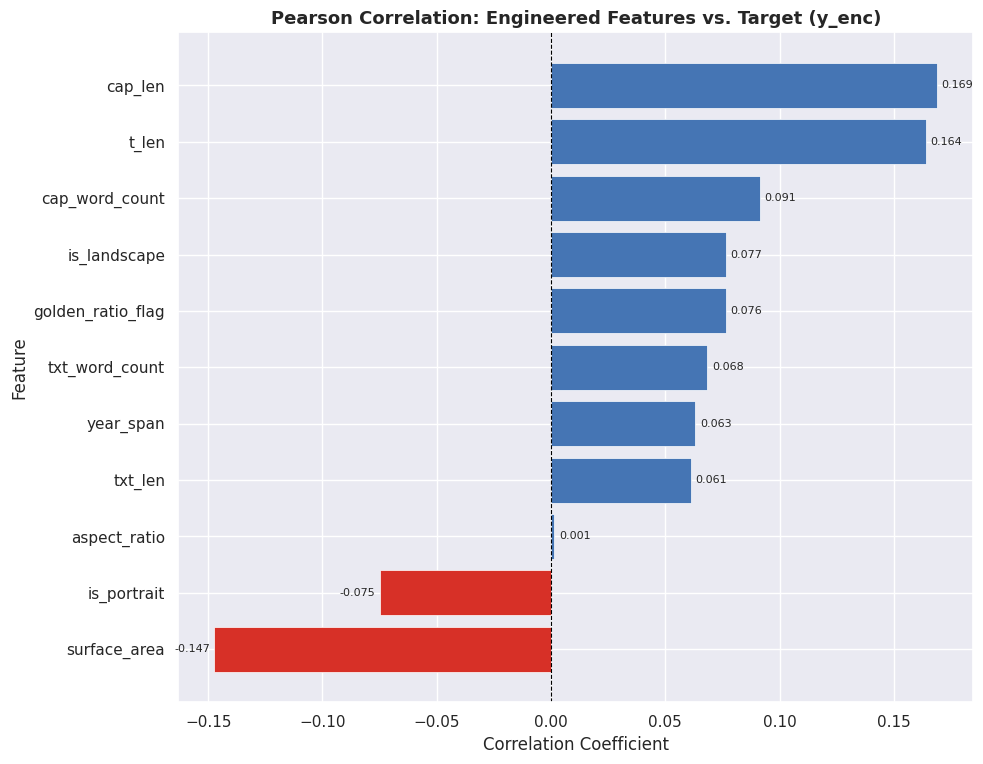

Plot 1: Pearson correlation bar chart rendered.


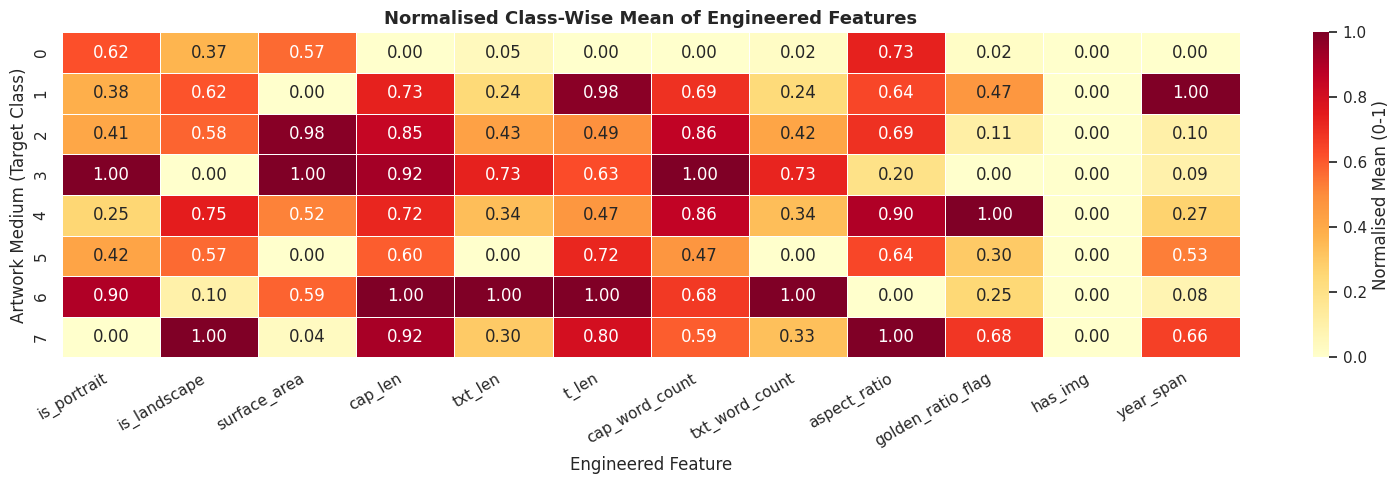

Plot 2: Class-wise normalised mean heatmap rendered.


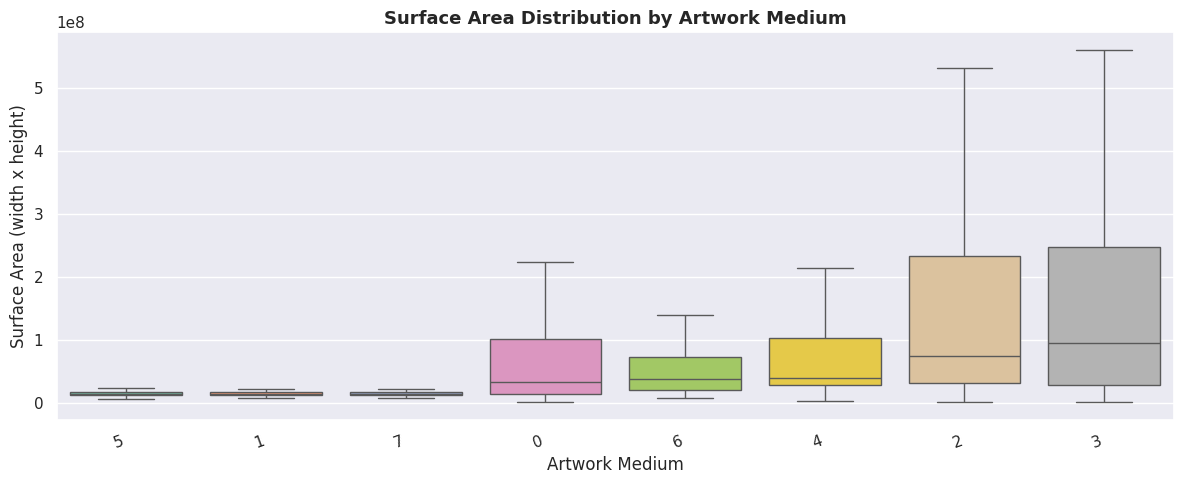

Plot 3: Surface area box-plots rendered.


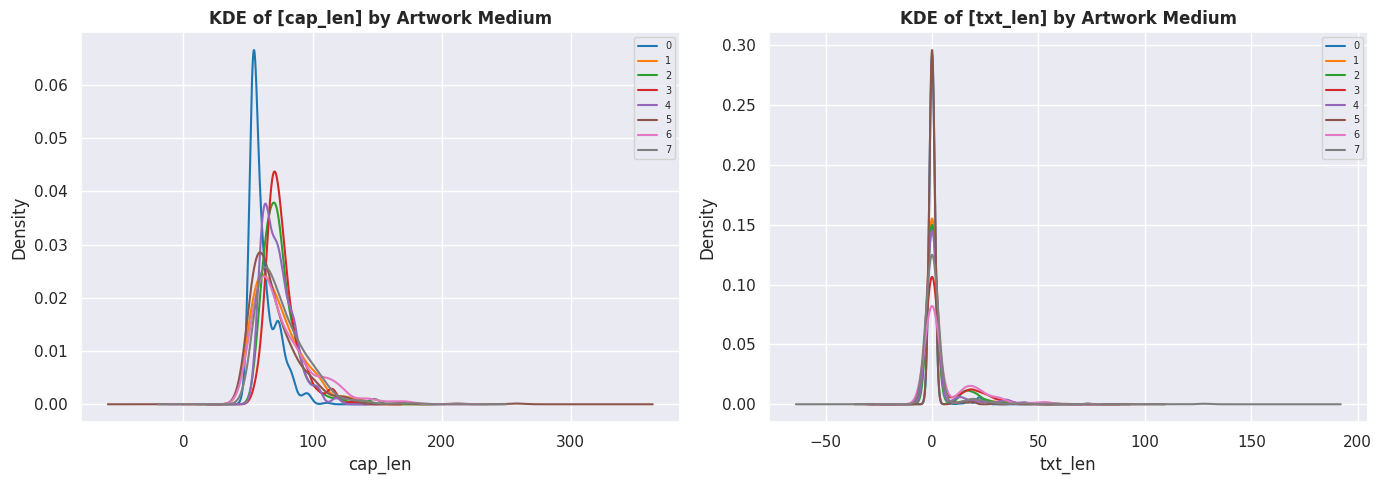

Plot 4: KDE text-length plots rendered.


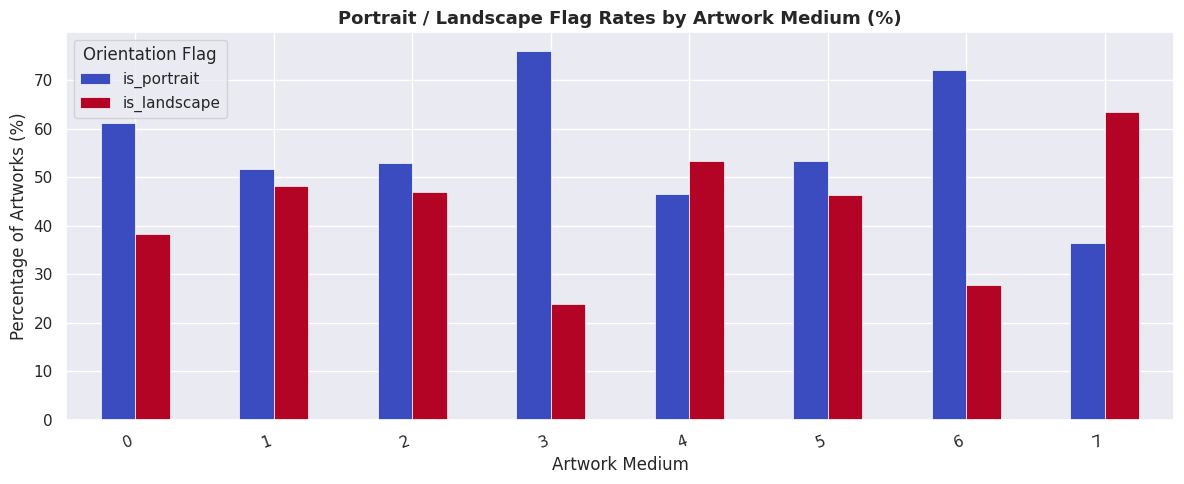

Plot 5: Orientation flag rates rendered.


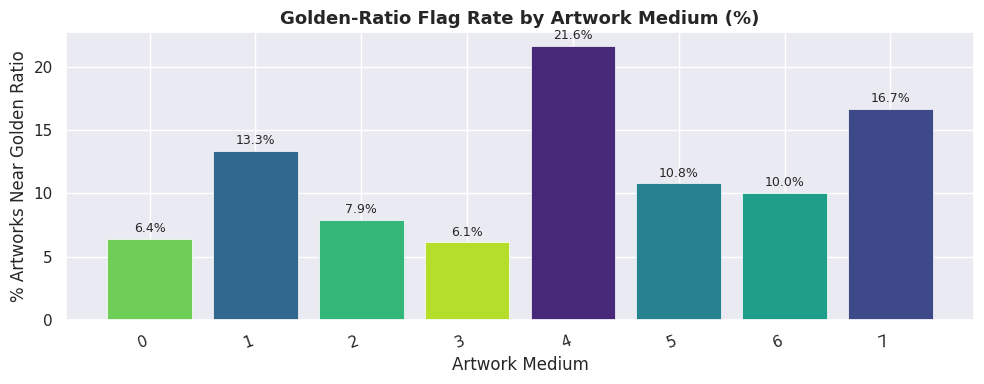

Plot 6: Golden-ratio flag rates rendered.
All feature target correlation visualisations completed successfully.


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid", palette="tab10")
TARGET = "y"

train_viz = train.copy()

# Encode target as integer for correlation computation
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
train_viz["y_enc"] = le.fit_transform(train_viz[TARGET])
classes = le.classes_

print("Target classes:", list(classes))

# Add engineered features if not already present
for df in [train_viz]:
    if "cap_len" not in df.columns and "cap" in df.columns:
        df["cap_len"] = df["cap"].fillna("").apply(len)
    if "txt_len" not in df.columns and "txt" in df.columns:
        df["txt_len"] = df["txt"].fillna("").apply(len)
    if "t_len" not in df.columns and "t" in df.columns:
        df["t_len"] = df["t"].fillna("").apply(len)
    if "cap_word_count" not in df.columns and "cap" in df.columns:
        df["cap_word_count"] = df["cap"].fillna("").apply(lambda x: len(x.split()))
    if "txt_word_count" not in df.columns and "txt" in df.columns:
        df["txt_word_count"] = df["txt"].fillna("").apply(lambda x: len(x.split()))
    if "aspect_ratio" not in df.columns and "width" in df.columns and "height" in df.columns:
        df["aspect_ratio"] = df["width"] / (df["height"] + 1e-9)
    if "golden_ratio_flag" not in df.columns and "aspect_ratio" in df.columns:
        df["golden_ratio_flag"] = (np.abs(df["aspect_ratio"] - 1.618) < 0.162).astype(int)
    if "has_img" not in df.columns and "img" in df.columns:
        df["has_img"] = df["img"].notna().astype(int)
    if "year_span" not in df.columns and "y0" in df.columns and "y1" in df.columns:
        df["year_span"] = df["y1"] - df["y0"]

engineered_cols = [
    "is_portrait", "is_landscape", "surface_area",
    "cap_len", "txt_len", "t_len",
    "cap_word_count", "txt_word_count",
    "aspect_ratio", "golden_ratio_flag",
    "has_img", "year_span"
]
avail_cols = [c for c in engineered_cols if c in train_viz.columns]
print("Available engineered features:", avail_cols)

# 1. Pearson correlation bar chart: 
corr_vals = train_viz[avail_cols + ["y_enc"]].corr()["y_enc"].drop("y_enc").sort_values()
fig, ax = plt.subplots(figsize=(10, max(4, len(avail_cols) * 0.65)))
colors = ["#d73027" if v < 0 else "#4575b4" for v in corr_vals.values]
bars = ax.barh(corr_vals.index, corr_vals.values, color=colors, edgecolor="white", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Pearson Correlation: Engineered Features vs. Target (y_enc)",
             fontweight="bold", fontsize=13)
ax.set_xlabel("Correlation Coefficient")
ax.set_ylabel("Feature")
for bar, val in zip(bars, corr_vals.values):
    ax.text(
        val + 0.002 if val >= 0 else val - 0.002,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}", va="center",
        ha="left" if val >= 0 else "right", fontsize=8
    )
plt.tight_layout()
plt.show()
print("Plot 1: Pearson correlation bar chart rendered.")

# 2. Class-wise mean heatmap:
class_means = train_viz.groupby(TARGET)[avail_cols].mean()
class_means_norm = (class_means - class_means.min()) / (class_means.max() - class_means.min() + 1e-9)
fig, ax = plt.subplots(figsize=(max(10, len(avail_cols) * 1.3), 5))
sns.heatmap(
    class_means_norm, annot=True, fmt=".2f", cmap="YlOrRd",
    linewidths=0.5, linecolor="white", ax=ax,
    cbar_kws={"label": "Normalised Mean (0-1)"}
)
ax.set_title("Normalised Class-Wise Mean of Engineered Features",
             fontweight="bold", fontsize=13)
ax.set_ylabel("Artwork Medium (Target Class)")
ax.set_xlabel("Engineered Feature")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
print("Plot 2: Class-wise normalised mean heatmap rendered.")

# 3. Surface area box plots:
if "surface_area" in train_viz.columns:
    fig, ax = plt.subplots(figsize=(12, 5))
    order = train_viz.groupby(TARGET)["surface_area"].median().sort_values().index
    sns.boxplot(data=train_viz, x=TARGET, y="surface_area",
                order=order, palette="Set2", ax=ax, showfliers=False)
    ax.set_title("Surface Area Distribution by Artwork Medium",
                 fontweight="bold", fontsize=13)
    ax.set_xlabel("Artwork Medium")
    ax.set_ylabel("Surface Area (width x height)")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()
    print("Plot 3: Surface area box-plots rendered.")

# 4. KDE plots of text-length features:
text_feats = [c for c in ["cap_len", "txt_len"] if c in train_viz.columns]
if text_feats:
    fig, axes = plt.subplots(1, len(text_feats), figsize=(7 * len(text_feats), 5))
    if len(text_feats) == 1:
        axes = [axes]
    palette_map = sns.color_palette("tab10", n_colors=len(classes))
    for ax, feat in zip(axes, text_feats):
        for cls, color in zip(classes, palette_map):
            subset = train_viz.loc[train_viz[TARGET] == cls, feat].dropna()
            if len(subset) > 1:
                subset.plot.kde(ax=ax, label=cls, color=color, linewidth=1.5)
        ax.set_title(f"KDE of [{feat}] by Artwork Medium",
                     fontweight="bold", fontsize=12)
        ax.set_xlabel(feat)
        ax.set_ylabel("Density")
        ax.legend(fontsize=7, loc="upper right")
    plt.tight_layout()
    plt.show()
    print("Plot 4: KDE text-length plots rendered.")

# 5. Orientation flag proportions:
orient_feats = [c for c in ["is_portrait", "is_landscape"] if c in train_viz.columns]
if orient_feats:
    orient_means = train_viz.groupby(TARGET)[orient_feats].mean() * 100
    fig, ax = plt.subplots(figsize=(12, 5))
    orient_means.plot(kind="bar", ax=ax, colormap="coolwarm",
                      edgecolor="white", linewidth=0.5)
    ax.set_title("Portrait / Landscape Flag Rates by Artwork Medium (%)",
                 fontweight="bold", fontsize=13)
    ax.set_xlabel("Artwork Medium")
    ax.set_ylabel("Percentage of Artworks (%)")
    ax.legend(title="Orientation Flag")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()
    print("Plot 5: Orientation flag rates rendered.")

# 6. Golden-ratio flag rates:
if "golden_ratio_flag" in train_viz.columns:
    gr_means = train_viz.groupby(TARGET)["golden_ratio_flag"].mean() * 100
    fig, ax = plt.subplots(figsize=(10, 4))
    sorted_gr = gr_means.sort_values(ascending=False)
    bar_colors = sns.color_palette("viridis", n_colors=len(sorted_gr))
    bars2 = ax.bar(sorted_gr.index, sorted_gr.values,
                   color=bar_colors, edgecolor="white", linewidth=0.5)
    ax.set_title("Golden-Ratio Flag Rate by Artwork Medium (%)",
                 fontweight="bold", fontsize=13)
    ax.set_xlabel("Artwork Medium")
    ax.set_ylabel("% Artworks Near Golden Ratio")
    for bar, val in zip(bars2, sorted_gr.values):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.3,
                f"{val:.1f}%", ha="center", va="bottom", fontsize=9)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()
    print("Plot 6: Golden-ratio flag rates rendered.")

print("All feature target correlation visualisations completed successfully.")


## Visual Correlation of Image Features:

The plots below show how `img_size_kb` and `img_complexity` relate to the artwork medium class. Higher file sizes often align with denser, higher-detail mediums (e.g., oil paintings). Higher complexity (Laplacian variance) tends to flag mediums with sharp edges, such as engravings and prints.

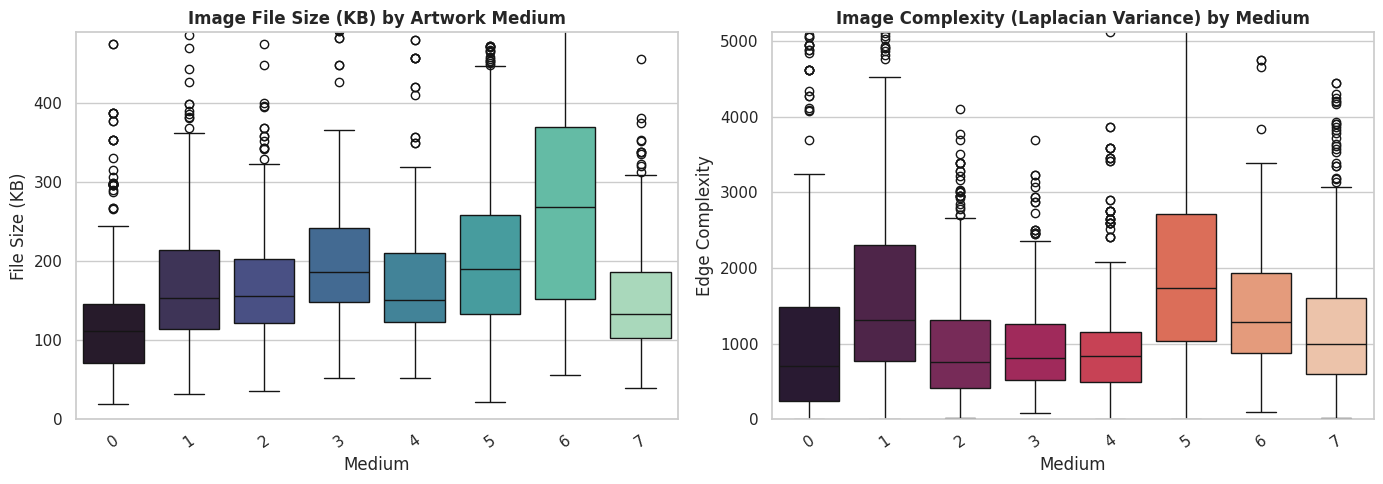

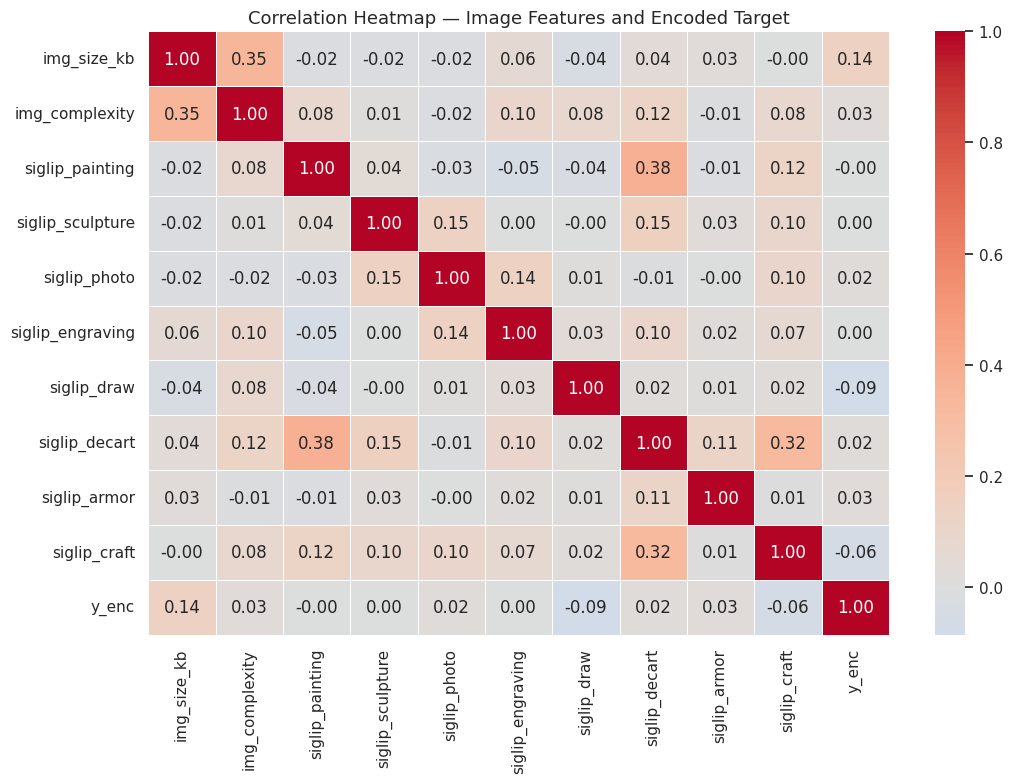

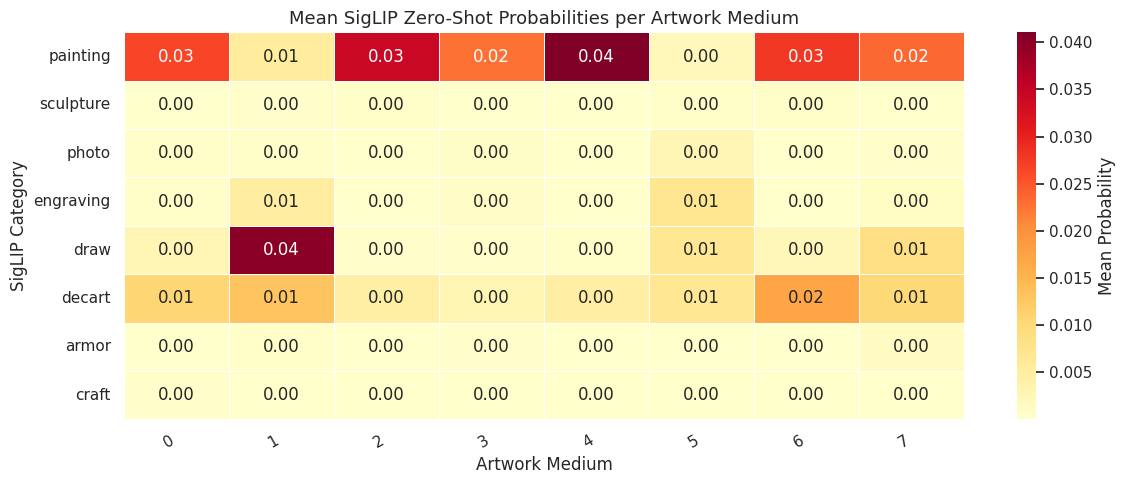

In [15]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train_fe = pd.read_csv('data/train_fe.csv')

sns.set_theme(style='whitegrid')

# 1. Image size (KB) by medium
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if 'img_size_kb' in train_fe.columns:
    data_size = train_fe[train_fe['img_size_kb'] > 0]
    sns.boxplot(data=data_size, x='y', y='img_size_kb', palette='mako', ax=axes[0])
    axes[0].set_title('Image File Size (KB) by Artwork Medium', fontweight='bold')
    axes[0].set_xlabel('Medium')
    axes[0].set_ylabel('File Size (KB)')
    axes[0].tick_params(axis='x', rotation=35)
    axes[0].set_ylim(0, data_size['img_size_kb'].quantile(0.98))

# 2. Image complexity by medium
if 'img_complexity' in train_fe.columns:
    data_cplx = train_fe[train_fe['img_complexity'] > 0]
    sns.boxplot(data=data_cplx, x='y', y='img_complexity', palette='rocket', ax=axes[1])
    axes[1].set_title('Image Complexity (Laplacian Variance) by Medium', fontweight='bold')
    axes[1].set_xlabel('Medium')
    axes[1].set_ylabel('Edge Complexity')
    axes[1].tick_params(axis='x', rotation=35)
    axes[1].set_ylim(0, data_cplx['img_complexity'].quantile(0.98))

plt.tight_layout()
plt.show()

# 3. Correlation heatmap — new image features + targets
img_feat_cols = [
    'img_size_kb', 'img_complexity',
    'siglip_painting', 'siglip_sculpture', 'siglip_photo', 'siglip_engraving',
    'siglip_draw', 'siglip_decart', 'siglip_armor', 'siglip_craft'
]
avail = [c for c in img_feat_cols if c in train_fe.columns]

if avail:
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    train_fe['y_enc'] = le.fit_transform(train_fe['y'])
    corr_df = train_fe[avail + ['y_enc']].dropna().corr()

    plt.figure(figsize=(11, 8))
    mask = corr_df.isnull()
    sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, linewidths=0.5, mask=mask)
    plt.title('Correlation Heatmap — Image Features and Encoded Target', fontsize=13)
    plt.tight_layout()
    plt.show()

# 4. SigLIP zero-shot probabilities across mediums
siglip_cols = [c for c in avail if c.startswith('siglip_')]
if siglip_cols and 'y' in train_fe.columns:
    mean_probs = train_fe.groupby('y')[siglip_cols].mean()
    mean_probs.columns = [c.replace('siglip_', '') for c in siglip_cols]

    plt.figure(figsize=(12, 5))
    sns.heatmap(mean_probs.T, annot=True, fmt='.2f', cmap='YlOrRd',
                linewidths=0.4, cbar_kws={'label': 'Mean Probability'})
    plt.title('Mean SigLIP Zero-Shot Probabilities per Artwork Medium', fontsize=13)
    plt.ylabel('SigLIP Category')
    plt.xlabel('Artwork Medium')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

---

**Thank You for reading this.**